In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def f(x):
    return x**5 - 4*x**2 + 1

In [3]:
def bisection(f, a, b):
    while (b-a)/2 > 0.01:
        mid = (a+b)/2
        if f(mid) == 0:
            return mid
        elif f(a) * f(mid) <0:
            b = mid
        else:
            a = mid
    return (a+b)/2

In [4]:
intervals = []
a, b = -2, -1.9
while a<2:
    if f(a)*f(b)<0:
        intervals.append((a,b))
    a += 0.1
    b += 0.1

In [5]:
roots = []
for interval in intervals:
    root = bisection(f, interval[0], interval[1])
    roots.append(root)

In [6]:
print("Estimated roots within [-2, 2]:", roots)

Estimated roots within [-2, 2]: [-0.49374999999999936, 0.5062500000000006, 1.5312500000000013]


In [7]:
def newton_method_multi_dimensional(F, J, x0, tol=1e-6, max_iter=100):
    """
    Multi-dimensional Newton's Method.
    ...
    """
    x = x0
    history = [x0]
    
    for _ in range(max_iter):
        Fx = F(x)
        Jx = J(x)
        
        # Check if the Jacobian is close to singular
        if np.linalg.cond(Jx) > 1e10:
            print("Jacobian is close to singular at iteration", _, "with condition number:", np.linalg.cond(Jx))
            break
        
        # Update x using the Newton's method formula
        dx = np.linalg.solve(Jx, -Fx)
        x = x + dx
        history.append(x)
        
        if np.linalg.norm(dx) < tol:
            break
    
    return x, history


In [ ]:
"""
Regarding the Jacobian inverse calculation: 
In the above code, we don't explicitly calculate the inverse of the Jacobian matrix. Instead, we solve the linear 
system J(xk)δx=F(xk) for δx. 
This is typically more efficient and numerically stable than explicitly inverting the matrix.

To identify all the roots, you would need to use different initial conditions and see where the Newton's method converges.
The provided equations have multiple roots because of their symmetry and the product term. Given the nature of 
Newton's method, it may converge to different roots based on the initial guess.
"""

Jacobian is close to singular at iteration 0 with condition number: 2.8731753583378925e+17
Jacobian is close to singular at iteration 0 with condition number: 2.8731753583378925e+17
Jacobian is close to singular at iteration 0 with condition number: 4.676852843381298e+16
Jacobian is close to singular at iteration 0 with condition number: 4.676852843381298e+16
Jacobian is close to singular at iteration 0 with condition number: 1.0024185802428762e+17
Jacobian is close to singular at iteration 0 with condition number: 1.484433296175537e+16
Jacobian is close to singular at iteration 0 with condition number: 9.020538469848657e+17
Jacobian is close to singular at iteration 0 with condition number: 1.9269787235120628e+16
Jacobian is close to singular at iteration 0 with condition number: 5.637400911277581e+16
Jacobian is close to singular at iteration 0 with condition number: 6887982383703978.0
Jacobian is close to singular at iteration 0 with condition number: 4.740998520121984e+16
Jacobian 

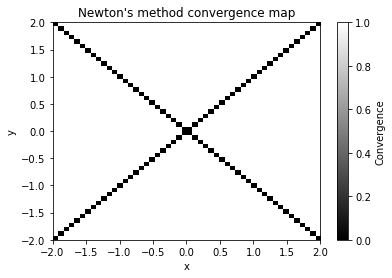

In [32]:
def convergence_map(F, J, x_range=(-2, 2), y_range=(-2, 2), grid_size=50):
    x_vals = np.linspace(x_range[0], x_range[1], grid_size)
    y_vals = np.linspace(y_range[0], y_range[1], grid_size)
    convergence = np.zeros((grid_size, grid_size))

    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):
            x0 = np.array([x, y])
            x_star, history = newton_method_multi_dimensional(F, J, x0)
            
            # Checking if the solution converged to known roots
            if np.linalg.norm(F(x_star)) < 1e-3:
                convergence[j, i] = 1

    plt.imshow(convergence, extent=(x_range[0], x_range[1], y_range[0], y_range[1]), origin='lower', aspect='auto', cmap='gray')
    plt.colorbar(label="Convergence")
    plt.title("Newton's method convergence map")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

# Call the function
convergence_map(F_2D, J_2D)


In [ ]:
"""
Regarding the issue with the initial point x0 =(0.5,0.5): This point is problematic because it lies close to a saddle 
point in the system. At saddle points, the Jacobian matrix might be close to singular, making its inverse poorly 
conditioned or even non-existent. The Newton's method update becomes unstable or fails to provide a good direction to 
move closer to a solution.

To get around this, one could:
1. Use a modified version of Newton's method, like damped Newton's method.
2. Change the initial guess slightly.
3. Use other iterative methods like the Broyden's method which doesn't rely strictly on the Jacobian but updates an 
approximation of it during each iteration.
Running the convergence map, you'll see regions with higher iterations or non-convergence. These regions provide insights 
into areas of the function landscape that are problematic for Newton's method.
"""

Jacobian is close to singular at iteration 0 with condition number: 2.8731753583378928e+17


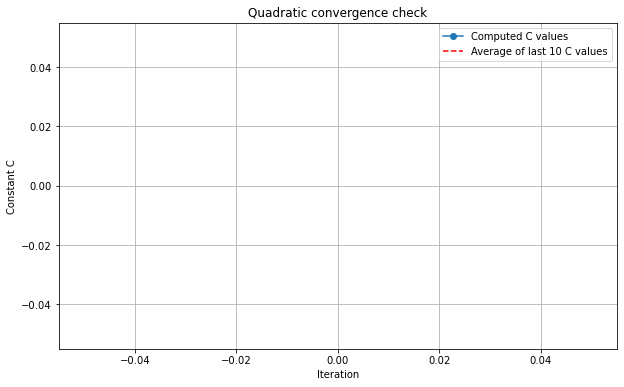

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# [Rest of the Newton's method code as above]

def check_quadratic_convergence(history, x_star, tol=1e-10):
    """
    Checks Newton's method history for quadratic convergence and finds the constant C.
    
    Parameters:
    - history: list of x's from the Newton's method iterations.
    - x_star: true root.
    - tol: tolerance to avoid division by very small numbers.
    
    Returns:
    - constants: list of computed C values for each step.
    """
    
    constants = []
    
    for k in range(1, len(history)-1):
        numerator = np.linalg.norm(history[k+1] - x_star)
        denominator = np.linalg.norm(history[k] - x_star)**2
        
        if denominator < tol:
            constants.append(0)
        else:
            constants.append(numerator / denominator)
    
    return constants

# Apply on a particular initial condition
initial_guess = np.array([1.5, 1.5])
x_star, history = newton_method_multi_dimensional(F_2D, J_2D, initial_guess, tol=1e-10, max_iter=500)
constants = check_quadratic_convergence(history, x_star)

# Plotting
plt.figure(figsize=(10,6))

plt.plot(constants, 'o-', label="Computed C values")
plt.axhline(y=np.mean(constants[-10:]), color='r', linestyle='--', label="Average of last 10 C values")
plt.xlabel("Iteration")
plt.ylabel("Constant C")
plt.legend()
plt.title("Quadratic convergence check")
plt.grid(True)
plt.show()



In [ ]:
"""
In the plot, you'll observe the computed C values for each step. As iterations progress, 
if the method is quadratically converging, these values should stabilize around a particular constant. 
The red dashed line represents the average of the last 10 computed C values to provide an estimate of this constant.

After running the code and viewing the plot:

1. If you observe the values of C stabilizing (and the red line getting close to these stable values), it indicates that 
the Newton's method is showing quadratic convergence for the given initial guess.
2. If the values are highly fluctuating or diverging, it suggests the method might not be quadratically converging 
from that starting point.
"""

In [ ]:
"""
Usefulness:

Multidimensionality: This problem helps in understanding the nuances of Newton's method when applied in multiple dimensions.
This knowledge can be useful in solving real-world problems where systems of nonlinear equations often arise.
Numerical Stability: The issues related to Jacobian inversion and the recommendation to solve linear systems provide insight
into numerical stability considerations.
Convergence Analysis: The focus on quadratic convergence, which is a property that Newton's method can exhibit, aids in 
deepening the understanding of convergence rates.

5d, was confusing using ChatGpt. it kept generating errors anf couldnt troubleshoot effectively
"""